# Model Evaluation

Training ml models is just the first step. The more important question is whether the model produces reliable predictions on patients it has never seen before. In this nb, the previously trained RSF is evaluated using several survival-specific metrics and visualizations. These analyses assess both the predictive accuracy of the model and its ability to distinguish between patients with different prognoses.

The primary objectives of this notebook are to:

- load the trained model,
- generate predictions on the test dataset,
- quantify predictive performance,
- visualize survival predictions,
- interpret the clinical usefulness of the model.

### A. Concordance Index (C-index)

The C-index is the most widely used evaluation metric in survival analysis. Unlike classification accuracy, which measures whether a prediction is correct or incorrect, the C-index measures how well a model ranks patients according to their risk.

Suppose two patients are compared. If the patient predicted to be at higher risk actually experiences the event earlier than the other patient, the prediction is considered **concordant**. The C-index is simply the proportion of all comparable patient pairs that are ranked correctly.

Typical interpretations are:

- **0.50** -> random guessing, like a 'coin flip' of sorts
- **0.60–0.70** -> reasonable predictive ability
- **0.70–0.80** -> strong model!
- **Above 0.80** -> excellent discrimination (rare in clinical datasets though)

Because it measures ranking rather than exact survival time, the C-index naturally handles censored observations and has become the standard performance metric for survival models.

## 1. Imports and Loading

In [19]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from sksurv.metrics import integrated_brier_score

In [2]:
rsf = joblib.load(
    "../models/random_survival_forest.pkl"
)

In [3]:
X_test = pd.read_csv("../data/processed/test_features.csv")

leakage_cols = [
    "death_from_cancer_Living",
    "death_from_cancer_Died of Other Causes"
]

X_test = X_test.drop(
    columns=leakage_cols,
    errors="ignore"
)

y_test_time = pd.read_csv(
    "../data/processed/test_time.csv"
).squeeze()

y_test_event = (
    pd.read_csv("../data/processed/test_event.csv")
    .squeeze()
    .astype(bool)
)

print(X_test.shape) 

(381, 722)


# 2. Prediction (Tests!) and Evaluation

In [ ]:
risk_scores = rsf.predict(
    X_test
)

risk_scores[:10]

In [ ]:
c_index = concordance_index_censored(
    y_test_event,
    y_test_time,
    risk_scores
)[0]

#print(f"C-index: {c_index:.3f}") verify, should be ~0.7

## Survival Functions

Rather than assigning only a single risk score, a RSF can estimate an entire survival curve for each patient. A survival curve shows the probability that a patient remains alive beyond different points in time. These curves provide substantially richer clinical information than a simple high-risk or low-risk classification because they describe how predicted survival changes throughout follow-up.

# 3. Survival Graphs 

In [9]:
survival_functions = rsf.predict_survival_function(
    X_test.iloc[:5]
)

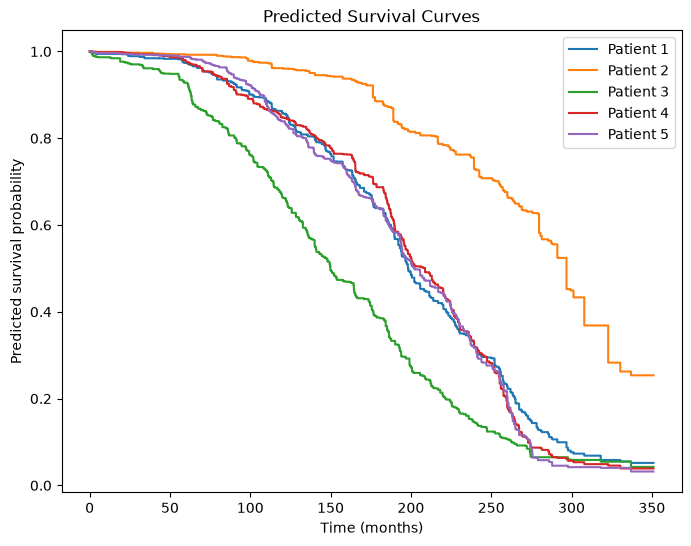

In [10]:
#matplotlib graphics for survival curves
plt.figure(figsize=(8,6))

for i, fn in enumerate(survival_functions):
    plt.step(
        fn.x,
        fn.y,
        where="post",
        label=f"Patient {i+1}"
    )

plt.xlabel("Time (months)")
plt.ylabel("Predicted survival probability")
plt.title("Predicted Survival Curves")
plt.legend()

# Save 
plt.savefig(
    "../figures/predicted_survival_curves.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Interpreting the Survival Curves

Each curve represents the predicted probability that a patient survives beyond a given point in time. A curve that declines rapidly indicates poorer predicted prognosis, whereas a flatter curve suggests better long-term survival. Comparing multiple curves shows how the RSF differentiates between patients with varying levels of predicted clinical risk.

# 4. Risk Score Distribution

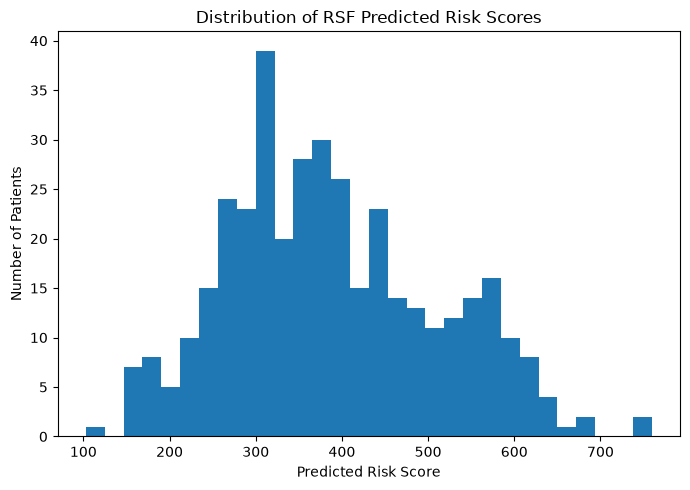

In [11]:
plt.figure(figsize=(7,5))

plt.hist(
    risk_scores,
    bins=30
)

plt.xlabel("Predicted Risk Score")
plt.ylabel("Number of Patients")
plt.title("Distribution of RSF Predicted Risk Scores")

plt.tight_layout()

plt.savefig(
    "../figures/risk_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

RSF generates relative risk scores, where higher values indicate greater predicted mortality risk. The distribution demonstrates variation in predicted risk across the test cohort.

# 5. Integrated Brier Score

In [22]:
# Load survival targets
train_event = pd.read_csv("../data/processed/train_event.csv").values.ravel()
train_time = pd.read_csv("../data/processed/train_time.csv").values.ravel()

test_event = pd.read_csv("../data/processed/test_event.csv").values.ravel()
test_time = pd.read_csv("../data/processed/test_time.csv").values.ravel()

# Convert to scikit-survival format
y_train = Surv.from_arrays(
    event=train_event.astype(bool),
    time=train_time
)

y_test = Surv.from_arrays(
    event=test_event.astype(bool),
    time=test_time
)

surv_funcs = rsf.predict_survival_function(X_test)

max_time = surv_funcs[0].domain[1]

times = np.linspace(
    test_time.min(),
    max_time,
    100
)

pred_surv = np.asarray([
    fn(times)
    for fn in surv_funcs
])

ibs = integrated_brier_score(
    y_train,
    y_test,
    pred_surv,
    times
)

print(f"Integrated Brier Score: {ibs:.4f}")

Integrated Brier Score: 0.0998
